#### Libraries

In [757]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder,OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report)
from imblearn.over_sampling import SMOTE


In [675]:
data=pd.read_csv("employee.csv")
data

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
54803,3030,Technology,region_14,Bachelor's,m,sourcing,1,48,3.0,17,0,78,0
54804,74592,Operations,region_27,Master's & above,f,other,1,37,2.0,6,0,56,0
54805,13918,Analytics,region_1,Bachelor's,m,other,1,27,5.0,3,0,79,0
54806,13614,Sales & Marketing,region_9,NaN,m,sourcing,1,29,1.0,2,0,45,0


## Data Underdtanding

In [676]:
data.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0


In [677]:
data.tail()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
54803,3030,Technology,region_14,Bachelor's,m,sourcing,1,48,3.0,17,0,78,0
54804,74592,Operations,region_27,Master's & above,f,other,1,37,2.0,6,0,56,0
54805,13918,Analytics,region_1,Bachelor's,m,other,1,27,5.0,3,0,79,0
54806,13614,Sales & Marketing,region_9,NaN,m,sourcing,1,29,1.0,2,0,45,0
54807,51526,HR,region_22,Bachelor's,m,other,1,27,1.0,5,0,49,0


In [678]:
data.shape

(54808, 13)

In [679]:
data.size

712504

In [680]:
data.dtypes

employee_id               int64
department                  str
region                      str
education                   str
gender                      str
recruitment_channel         str
no_of_trainings           int64
age                       int64
previous_year_rating    float64
length_of_service         int64
awards_won?               int64
avg_training_score        int64
is_promoted               int64
dtype: object

In [681]:
data.columns = data.columns.str.replace('?', '').str.strip()

In [682]:
data.columns

Index(['employee_id', 'department', 'region', 'education', 'gender',
       'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'awards_won', 'avg_training_score', 'is_promoted'],
      dtype='str')

In [683]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  str    
 2   region                54808 non-null  str    
 3   education             52399 non-null  str    
 4   gender                54808 non-null  str    
 5   recruitment_channel   54808 non-null  str    
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  awards_won            54808 non-null  int64  
 11  avg_training_score    54808 non-null  int64  
 12  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(7), str(5)
memory usage: 7.5 MB


In [684]:
data.nunique()

employee_id             54808
department                  9
region                     34
education                   3
gender                      2
recruitment_channel         3
no_of_trainings            10
age                        41
previous_year_rating        5
length_of_service          35
awards_won                  2
avg_training_score         61
is_promoted                 2
dtype: int64

In [685]:
data.department.unique()

<ArrowStringArray>
['Sales & Marketing',        'Operations',        'Technology',
         'Analytics',               'R&D',       'Procurement',
           'Finance',                'HR',             'Legal']
Length: 9, dtype: str

In [686]:
data.region.unique()

<ArrowStringArray>
[ 'region_7', 'region_22', 'region_19', 'region_23', 'region_26',  'region_2',
 'region_20', 'region_34',  'region_1',  'region_4', 'region_29', 'region_31',
 'region_15', 'region_14', 'region_11',  'region_5', 'region_28', 'region_17',
 'region_13', 'region_16', 'region_25', 'region_10', 'region_27', 'region_30',
 'region_12', 'region_21',  'region_8', 'region_32',  'region_6', 'region_33',
 'region_24',  'region_3',  'region_9', 'region_18']
Length: 34, dtype: str

In [687]:
data.education.unique()

<ArrowStringArray>
['Master's & above', 'Bachelor's', nan, 'Below Secondary']
Length: 4, dtype: str

In [688]:
data.recruitment_channel.unique()

<ArrowStringArray>
['sourcing', 'other', 'referred']
Length: 3, dtype: str

In [689]:
data.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted
count,54808.000000,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,54808.000000,54808.000000
mean,39195.830627,1.253011,34.803915,3.329256,5.865512,0.023172,63.386750,0.085170
std,22586.581449,0.609264,7.660169,1.259993,4.265094,0.150450,13.371559,0.279137
min,1.000000,1.000000,20.000000,1.000000,1.000000,0.000000,39.000000,0.000000
25%,19669.750000,1.000000,29.000000,3.000000,3.000000,0.000000,51.000000,0.000000
50%,39225.500000,1.000000,33.000000,3.000000,5.000000,0.000000,60.000000,0.000000
75%,58730.500000,1.000000,39.000000,4.000000,7.000000,0.000000,76.000000,0.000000
max,78298.000000,10.000000,60.000000,5.000000,37.000000,1.000000,99.000000,1.000000


In [690]:
data.is_promoted.value_counts()

is_promoted
0    50140
1     4668
Name: count, dtype: int64

In [691]:
c=data.select_dtypes(include="number").corr()
c

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted
employee_id,1.000000,-0.005121,0.000437,0.004533,0.001274,0.008420,-0.000586,0.001206
no_of_trainings,-0.005121,1.000000,-0.081278,-0.063126,-0.057275,-0.007628,0.042517,-0.024896
age,0.000437,-0.081278,1.000000,0.006008,0.657111,-0.008169,-0.048380,-0.017166
previous_year_rating,0.004533,-0.063126,0.006008,1.000000,0.000253,0.027738,0.075139,0.159320
length_of_service,0.001274,-0.057275,0.657111,0.000253,1.000000,-0.039927,-0.038122,-0.010670
awards_won,0.008420,-0.007628,-0.008169,0.027738,-0.039927,1.000000,0.072138,0.195871
avg_training_score,-0.000586,0.042517,-0.048380,0.075139,-0.038122,0.072138,1.000000,0.181147
is_promoted,0.001206,-0.024896,-0.017166,0.159320,-0.010670,0.195871,0.181147,1.000000


## Exploratory Data Analysis

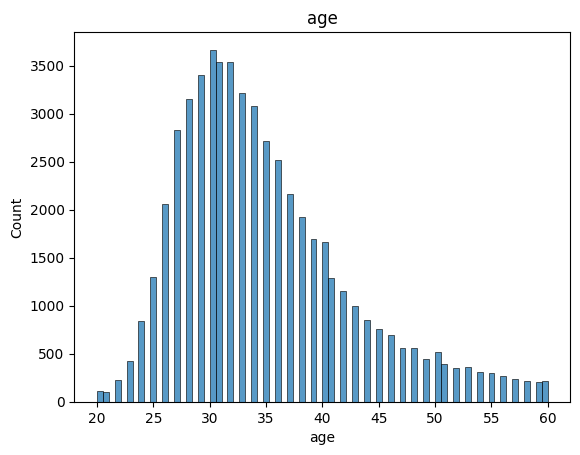

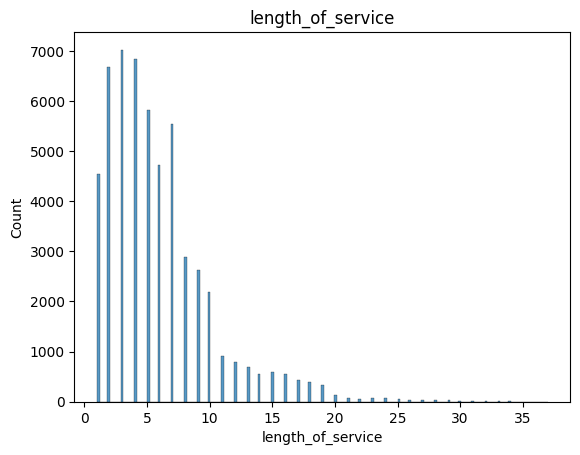

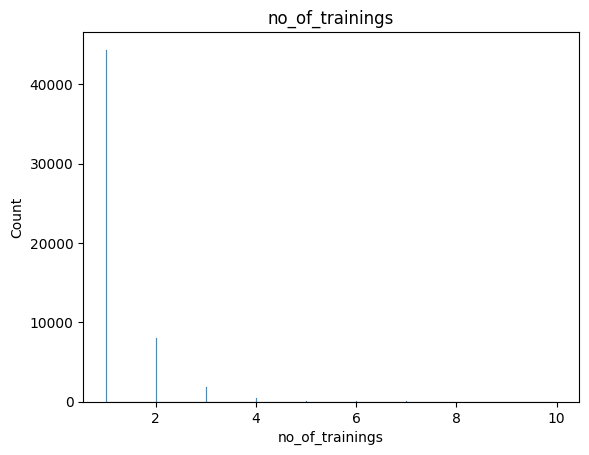

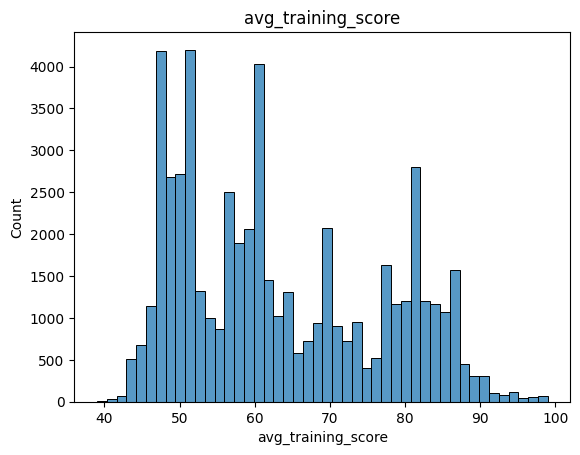

In [692]:
#Histplot of numerical values
col=[
    "age",
    "length_of_service",
   'no_of_trainings',
    "avg_training_score"]
for i in col:
    plt.figure()
    sns.histplot(data[i])    
    plt.title(i)

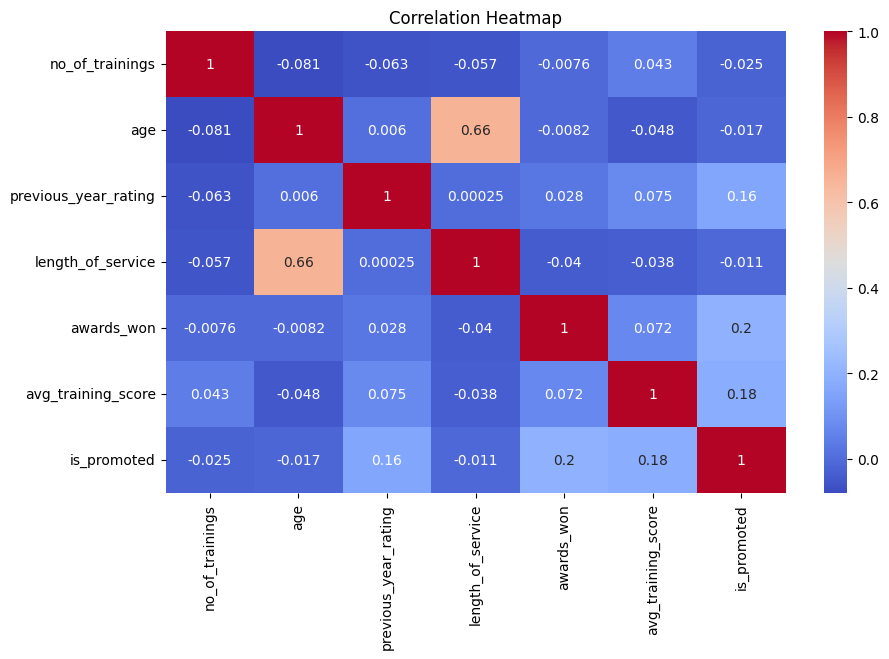

In [693]:
# Remove useless column
data = data.drop('employee_id', axis=1)
clean = data

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(clean.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

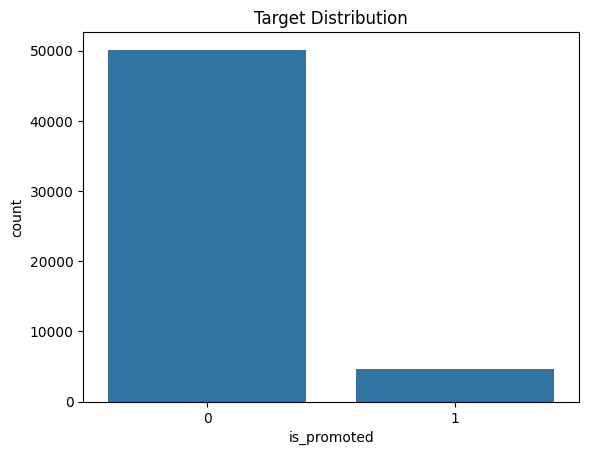

In [694]:
# CountPlot
# Count of target value
import seaborn as sns
sns.countplot(x='is_promoted',data=data)
plt.title("Target Distribution")
plt.show()

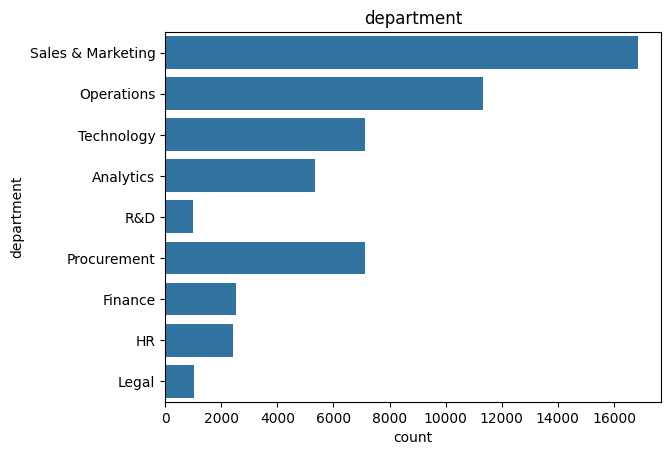

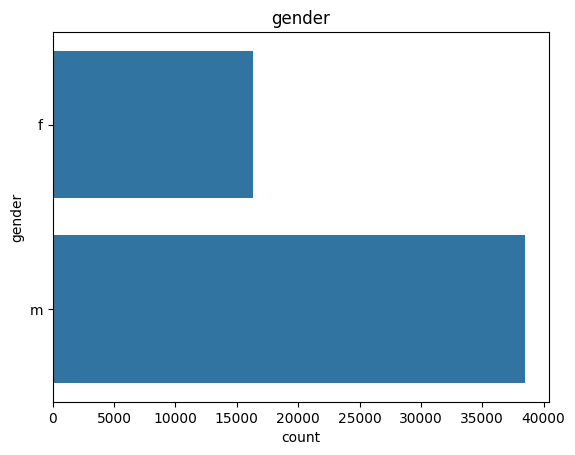

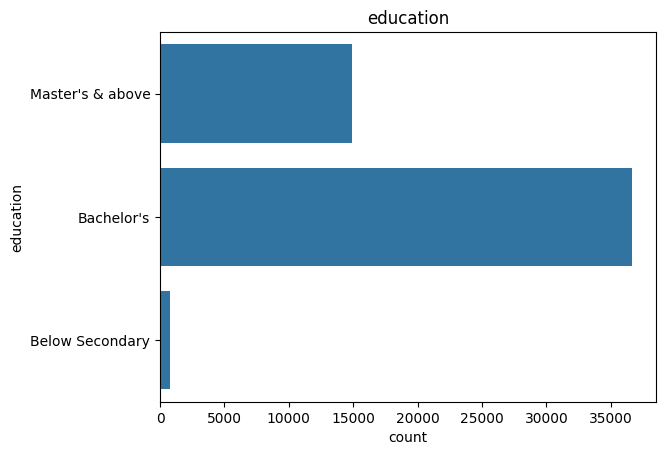

In [695]:
#countplot of categorical values
for i in ['department','gender','education']:
    sns.countplot(data[i])
    plt.title(i)
    plt.show()

In [696]:
data.dtypes

employee_id               int64
department                  str
region                      str
education                   str
gender                      str
recruitment_channel         str
no_of_trainings           int64
age                       int64
previous_year_rating    float64
length_of_service         int64
awards_won                int64
avg_training_score        int64
is_promoted               int64
dtype: object

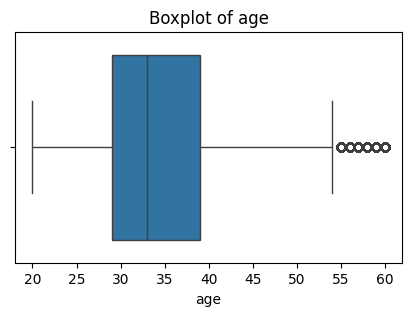

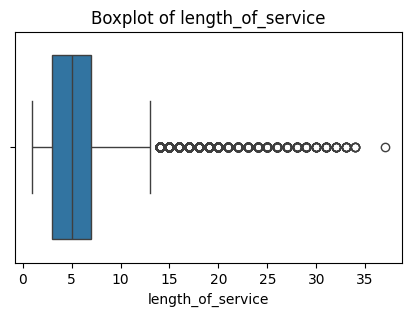

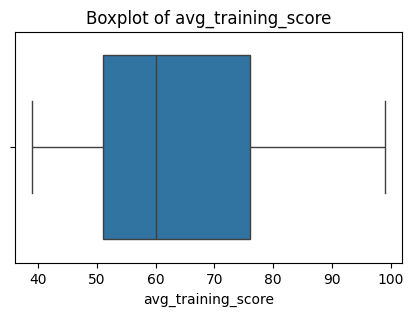

In [697]:
cols = [
 'age',
 'length_of_service',
 'avg_training_score'
]
for i in cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=data[i])
    plt.title(f"Boxplot of {i}")
    plt.show()

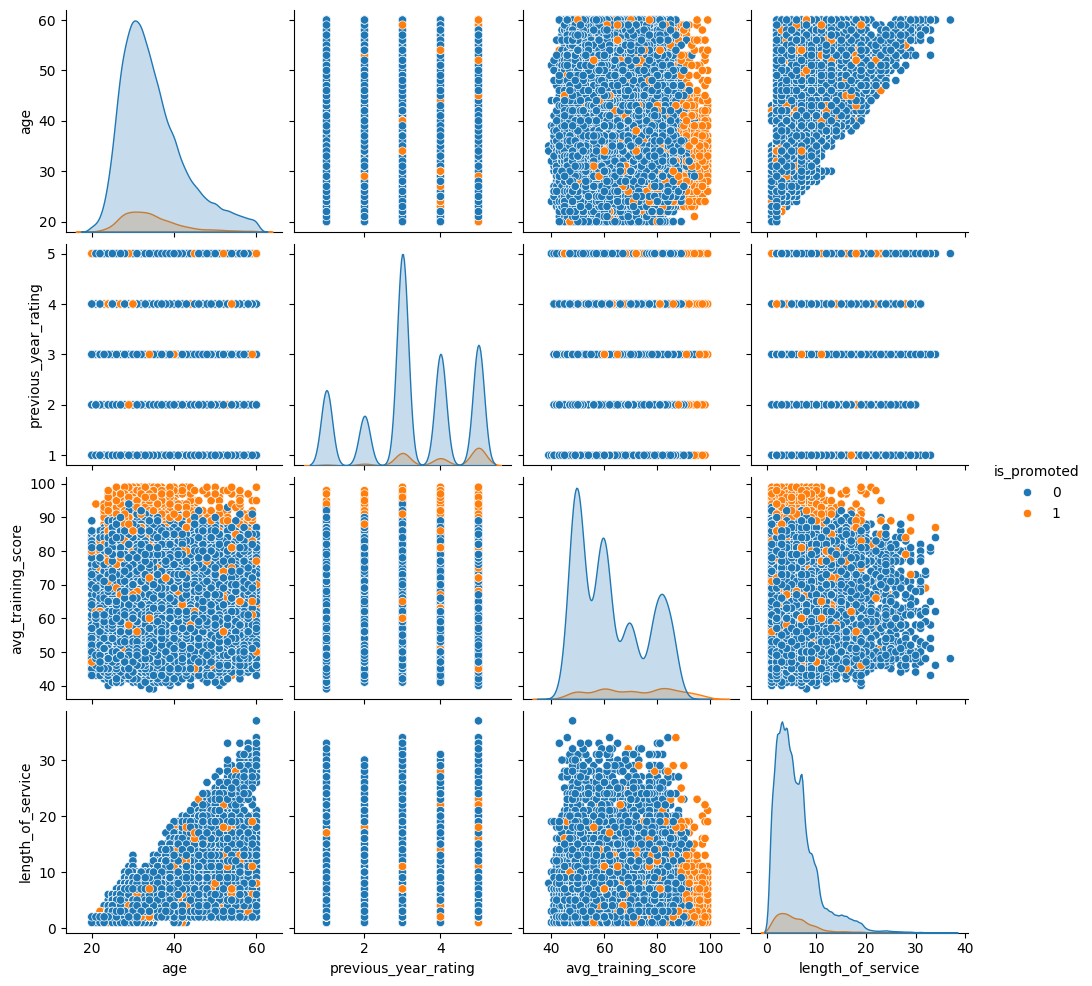

In [698]:
#A pairplot shows relationships between multiple numerical features:
#scatter plots between feature pairs
#histograms/diagonal distributions
cols = ['age', 'previous_year_rating', 'avg_training_score', 'length_of_service', 'is_promoted']
sns.pairplot(data[cols], hue='is_promoted')
plt.show()

## Data Preprocessing

In [699]:
data.isnull().sum()

employee_id                0
department                 0
region                     0
education               2409
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4124
length_of_service          0
awards_won                 0
avg_training_score         0
is_promoted                0
dtype: int64

In [ ]:
# mode is the most frequently occuring value , in case of categorical values we use mode and median and mean is for numerical values
data['education'] = data['education'].fillna(data['education'].mode()[0])
data['previous_year_rating']=data['previous_year_rating'].fillna(data['previous_year_rating'].median())

In [701]:
data.isna().sum()

employee_id             0
department              0
region                  0
education               0
gender                  0
recruitment_channel     0
no_of_trainings         0
age                     0
previous_year_rating    0
length_of_service       0
awards_won              0
avg_training_score      0
is_promoted             0
dtype: int64

In [702]:
data.duplicated().sum()

np.int64(0)

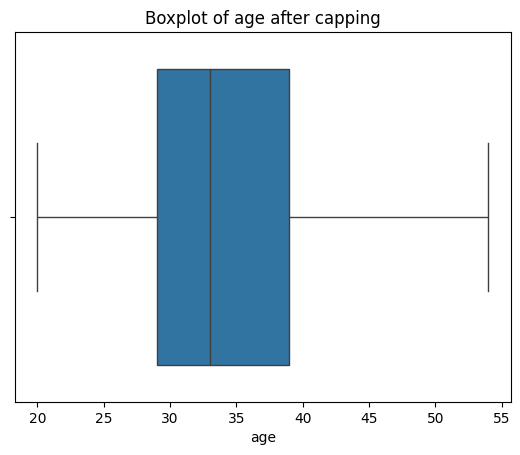

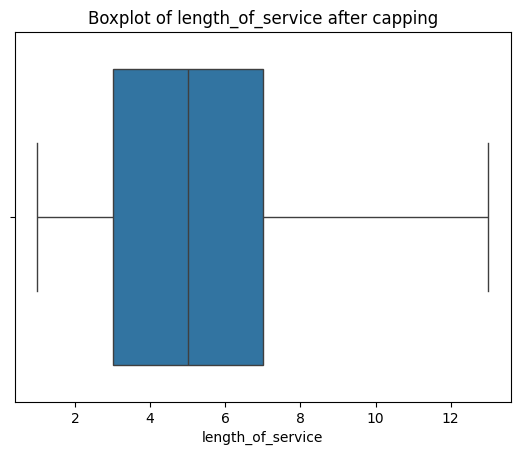

In [703]:
# Treat Outliers

lst = ['age', 'length_of_service']
for i in lst:
    Q1 = data[i].quantile(0.25)
    Q3 = data[i].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    data.loc[data[i] > upper_limit, i] = int(np.ceil(upper_limit))
    data.loc[data[i] < lower_limit, i] = int(np.floor(lower_limit))
    sns.boxplot(x=data[i])
    plt.title(f"Boxplot of {i} after capping")
    plt.show()

In [704]:
data.dtypes

employee_id               int64
department                  str
region                      str
education                   str
gender                      str
recruitment_channel         str
no_of_trainings           int64
age                       int64
previous_year_rating    float64
length_of_service         int64
awards_won                int64
avg_training_score        int64
is_promoted               int64
dtype: object

In [ ]:
# OrdinalEncoder:-to convert categorical data into numerical data (to get in order)
l1 = LabelEncoder()
l2=LabelEncoder()
l3=LabelEncoder()
l4=LabelEncoder()
oe = OrdinalEncoder()

data['department'] = l1.fit_transform(data['department'])
data['region'] = l2.fit_transform(data['region'])
data['gender']=l3.fit_transform(data['gender'])
data['recruitment_channel']=l4.fit_transform(data['recruitment_channel'])
data['education'] = oe.fit_transform(data[['education']])

In [706]:
x=data.drop('is_promoted', axis=1)
y=data['is_promoted']

In [707]:
x

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score
0,65438,7,31,2.0,0,2,1,35,5.0,8,0,49
1,65141,4,14,0.0,1,0,1,30,5.0,4,0,60
2,7513,7,10,0.0,1,2,1,34,3.0,7,0,50
3,2542,7,15,0.0,1,0,2,39,1.0,10,0,50
4,48945,8,18,0.0,1,0,1,45,3.0,2,0,73
...,...,...,...,...,...,...,...,...,...,...,...,...
54803,3030,8,5,0.0,1,2,1,48,3.0,13,0,78
54804,74592,4,19,2.0,0,0,1,37,2.0,6,0,56
54805,13918,0,0,0.0,1,0,1,27,5.0,3,0,79
54806,13614,7,33,0.0,1,2,1,29,1.0,2,0,45


In [708]:
y

0        0
1        0
2        0
3        0
4        0
        ..
54803    0
54804    0
54805    0
54806    0
54807    0
Name: is_promoted, Length: 54808, dtype: int64

### Train Split

In [709]:
#SMOTE--->synthetic minority oversampling Technique
from imblearn.over_sampling import SMOTE

# Apply SMOTE only on training data
sm = SMOTE(random_state=42)
x_res, y_res = sm.fit_resample(x, y)

In [710]:
y_res.value_counts()

is_promoted
0    50140
1    50140
Name: count, dtype: int64

In [711]:
x_train,x_test,y_train,y_test=train_test_split(x_res,y_res,test_size=0.2,random_state=42)

In [712]:
print("X_train shape:", x_train.shape)
print("X_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)    

X_train shape: (80224, 12)
X_test shape: (20056, 12)
y_train shape: (80224,)
y_test shape: (20056,)


In [ ]:
scaler = StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [714]:
x_train.shape

(80224, 12)

## Model Building

#### 1.LOGISTIC REGRESSION

In [ ]:
logistic=LogisticRegression()
logistic.fit(x_train,y_train)


y_pred_l=logistic.predict(x_test)
print(y_pred_l)

print("LOGISTIC REGRESSION Accuracy:", accuracy_score(y_test, y_pred_l))

[1 1 0 ... 0 1 1]
LOGISTIC REGRESSION Accuracy: 0.702682489030714


#### After hyperparameter tuning

In [723]:
lg_params= {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
    'penalty': ['l1', 'l2']
    }

lg_grid= GridSearchCV(
    estimator=logistic,
    param_grid=lg_params,
    cv=5,
    scoring='accuracy'
)

lg_grid.fit(x_train, y_train)
print("Best Parameters:", lg_grid.best_params_)

Best Parameters: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}


In [739]:
logistic1=LogisticRegression(C=10, solver='lbfgs', penalty='l2')
logistic1.fit(x_train,y_train)

y_pred_l1=logistic1.predict(x_test)
print(y_pred_l1)

print("LOGISTIC REGRESSION\n_______________________________________\n")

print(" After Hyperparameter Tuning - LOGISTIC REGRESSION Accuracy:", accuracy_score(y_test, y_pred_l1))

print("\nTest Score  : ",logistic1.score(x_test,y_test))
print("Train Score : ",logistic1.score(x_train,y_train))

print("\nClassification report:\n", classification_report(y_test, y_pred_l1))


[1 1 0 ... 0 1 1]
LOGISTIC REGRESSION
_______________________________________

 After Hyperparameter Tuning - LOGISTIC REGRESSION Accuracy: 0.702682489030714

Test Score  :  0.702682489030714
Train Score :  0.7075688073394495

Classification report:
               precision    recall  f1-score   support

           0       0.72      0.68      0.70     10197
           1       0.69      0.72      0.70      9859

    accuracy                           0.70     20056
   macro avg       0.70      0.70      0.70     20056
weighted avg       0.70      0.70      0.70     20056



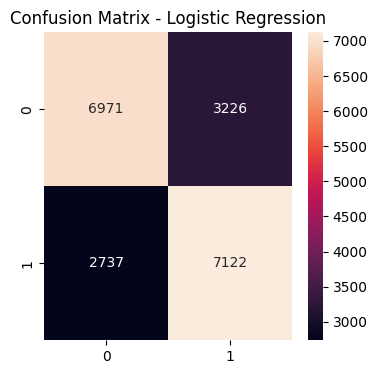

In [741]:
cm_lg= confusion_matrix(y_test, y_pred_l1)
plt.figure(figsize=(4,4))
sns.heatmap(cm_lg, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

#### 2.KNN [K-NEAREST KNEIGHBOURS]

In [722]:
knn = KNeighborsClassifier()
knn.fit(x_train, y_train)

y_pred_knn = knn.predict(x_test)
print(y_pred_knn)

print("K-NEAREST NEIGHBORS Accuracy:", accuracy_score(y_test, y_pred_knn))

[1 1 1 ... 0 1 1]
K-NEAREST NEIGHBORS Accuracy: 0.8607399282010371


#### After hyperparameter tuning

In [726]:
knn_params = {
    'n_neighbors': [3,5,7,9],
    'weights': ['uniform','distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(knn, param_grid=knn_params, cv=3)
knn_grid.fit(x_train, y_train)

print(knn_grid.best_params_)

{'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}


In [740]:
knn1=KNeighborsClassifier(n_neighbors=5,weights='distance',metric='manhattan')
knn1.fit(x_train, y_train)

y_pred_knn1 = knn1.predict(x_test)
print(y_pred_knn1)
print("K-NEAREST NEIGHBORS\n_______________________________________\n")

print(" After Hyperparameter Tuning - K-NEAREST NEIGHBORS Accuracy:", accuracy_score(y_test, y_pred_knn1))

print("\nTest Score  : ",knn1.score(x_test,y_test))
print("Train Score : ",knn1.score(x_train,y_train))

print("\nClassification report:\n", classification_report(y_test, y_pred_knn1))

[1 1 0 ... 0 1 0]
K-NEAREST NEIGHBORS
_______________________________________

 After Hyperparameter Tuning - K-NEAREST NEIGHBORS Accuracy: 0.9063621858795373

Test Score  :  0.9063621858795373
Train Score :  1.0

Classification report:
               precision    recall  f1-score   support

           0       0.91      0.90      0.91     10197
           1       0.90      0.91      0.91      9859

    accuracy                           0.91     20056
   macro avg       0.91      0.91      0.91     20056
weighted avg       0.91      0.91      0.91     20056



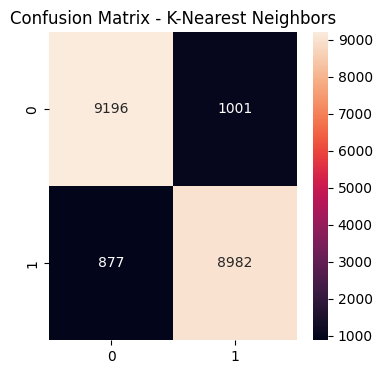

In [742]:
cm_knn= confusion_matrix(y_test,y_pred_knn1)
plt.figure(figsize=(4,4))
sns.heatmap(cm_knn, annot=True, fmt='d')
plt.title("Confusion Matrix - K-Nearest Neighbors")
plt.show()

#### 3.SVM [SUPPORT VECTOR MACHINE]

In [ ]:
#Support Vector Classifier
svm = SVC()
svm.fit(x_train, y_train)

y_pred_svm = svm.predict(x_test)
print(y_pred_svm)

print("SUPPORT VECTOR MACHINE Accuracy:", accuracy_score(y_test, y_pred_svm))


[1 1 0 ... 0 1 0]
SUPPORT VECTOR MACHINE Accuracy: 0.8285799760670124


#### After Hyperparameter tuning

In [738]:
svm_param= {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}
svm_grid = GridSearchCV(
    estimator=svm,
    param_grid=svm_param,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

svm_grid.fit(x_train,y_train)
print("Best Parameters:", svm_grid.best_params_)

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [744]:
svm1=SVC(C=10, kernel='rbf', gamma='scale')
svm1.fit(x_train, y_train)

y_pred_svm1 = svm1.predict(x_test)
print(y_pred_svm1)

print("SUPPORT VECTOR MACHINE\n_______________________________________\n")
print(" After Hyperparameter Tuning - SUPPORT VECTOR MACHINE Accuracy:", accuracy_score(y_test, y_pred_svm1))

print("\nTest Score  : ",svm1.score(x_test,y_test))
print("Train Score : ",svm1.score(x_train,y_train))

print("\nClassification report:\n", classification_report(y_test, y_pred_svm1))

[1 1 0 ... 0 1 0]
SUPPORT VECTOR MACHINE
_______________________________________

 After Hyperparameter Tuning - SUPPORT VECTOR MACHINE Accuracy: 0.8504686876745113

Test Score  :  0.8504686876745113
Train Score :  0.8717216792979657

Classification report:
               precision    recall  f1-score   support

           0       0.82      0.91      0.86     10197
           1       0.89      0.79      0.84      9859

    accuracy                           0.85     20056
   macro avg       0.86      0.85      0.85     20056
weighted avg       0.85      0.85      0.85     20056



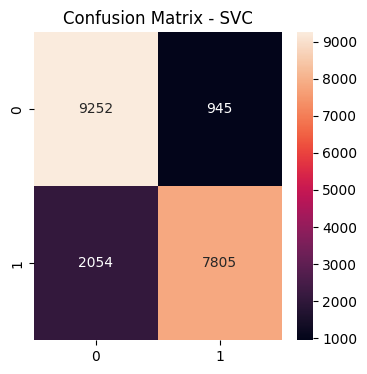

In [745]:
cm_svm = confusion_matrix(y_test, y_pred_svm1)
plt.figure(figsize=(4,4))
sns.heatmap(cm_svm, annot=True, fmt='d')
plt.title("Confusion Matrix - SVC")
plt.show()

#### 4.NAIVE BAYES

In [746]:
nb = GaussianNB()
nb.fit(x_train, y_train)

y_pred_nb = nb.predict(x_test)
print(y_pred_nb)

print("NAIVE BAYES Accuracy:", accuracy_score(y_test, y_pred_nb))

[1 1 1 ... 0 1 1]
NAIVE BAYES Accuracy: 0.7137016354208217


#### After Hyperparameter Tuning

In [747]:
nb_param = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
}

nb_grid = GridSearchCV(nb, param_grid=nb_param,scoring='accuracy', cv=5)
nb_grid.fit(x_train, y_train)

print(nb_grid.best_params_)

{'var_smoothing': 1e-09}


In [748]:
nb1=GaussianNB(var_smoothing=1e-09)
nb1.fit(x_train, y_train)


y_pred_nb1 = nb1.predict(x_test)
print(y_pred_nb1)

print("NAIVE BAYES\n_______________________________________\n")
print(" After Hyperparameter Tuning - NAIVE BAYES Accuracy:", accuracy_score(y_test, y_pred_nb1))

print("\nTest Score  : ",nb1.score(x_test,y_test))
print("Train Score : ",nb1.score(x_train,y_train))

print("\nClassification report:\n", classification_report(y_test, y_pred_nb1))

[1 1 1 ... 0 1 1]
NAIVE BAYES
_______________________________________

 After Hyperparameter Tuning - NAIVE BAYES Accuracy: 0.7137016354208217

Test Score  :  0.7137016354208217
Train Score :  0.7205325089748703

Classification report:
               precision    recall  f1-score   support

           0       0.77      0.62      0.69     10197
           1       0.67      0.81      0.74      9859

    accuracy                           0.71     20056
   macro avg       0.72      0.72      0.71     20056
weighted avg       0.72      0.71      0.71     20056



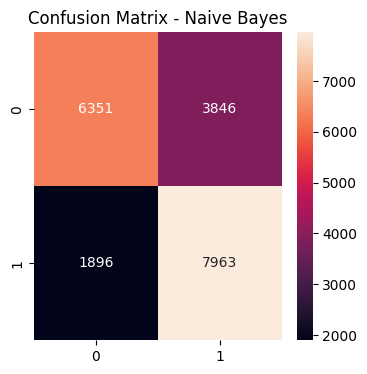

In [770]:
cm_nb = confusion_matrix(y_test, y_pred_nb1)
plt.figure(figsize=(4,4))
sns.heatmap(cm_nb, annot=True, fmt='d')
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

#### 5.DECISION TREE

In [750]:
dt=DecisionTreeClassifier()
dt.fit(x_train, y_train)

y_pred_dt = dt.predict(x_test)
print(y_pred_dt)
print("DECISION TREE Accuracy:", accuracy_score(y_test, y_pred_dt))

[1 1 1 ... 0 1 0]
DECISION TREE Accuracy: 0.9157359393697646


#### After Hyperparameter Tuning

In [751]:
dt_param = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3,5,10],
    'min_samples_split': [2, 5, 10]
}
dt_grid=GridSearchCV(dt, param_grid=dt_param, cv=5, scoring='accuracy')
dt_grid.fit(x_train, y_train)
print("Best parameters:", dt_grid.best_params_)

Best parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 2}


In [752]:
dt1=DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_split=2)
dt1.fit(x_train, y_train)

y_pred_dt1 = dt1.predict(x_test)
print(y_pred_dt1)

print("DECISION TREE\n_______________________________________\n")
print(" After Hyperparameter Tuning - DECISION TREE Accuracy:", accuracy_score(y_test, y_pred_dt1))

print("\nTest Score  : ",dt1.score(x_test,y_test))
print("Train Score : ",dt1.score(x_train,y_train))

print("\nClassification report:\n", classification_report(y_test, y_pred_dt1))

[1 1 0 ... 0 1 0]
DECISION TREE
_______________________________________

 After Hyperparameter Tuning - DECISION TREE Accuracy: 0.9092042281611488

Test Score  :  0.9092042281611488
Train Score :  0.9085809732748305

Classification report:
               precision    recall  f1-score   support

           0       0.87      0.96      0.91     10197
           1       0.95      0.86      0.90      9859

    accuracy                           0.91     20056
   macro avg       0.91      0.91      0.91     20056
weighted avg       0.91      0.91      0.91     20056



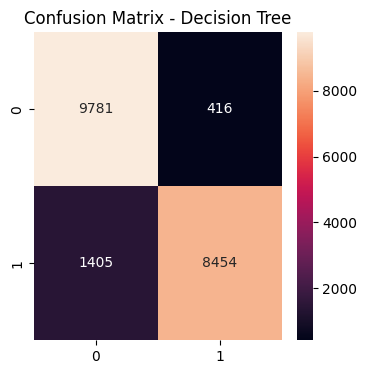

In [769]:
cm_dt = confusion_matrix(y_test, y_pred_dt1)
plt.figure(figsize=(4,4))
sns.heatmap(cm_dt, annot=True, fmt='d')
plt.title("Confusion Matrix - Decision Tree")
plt.show()

#### 6.RANDOM FOREST

In [ ]:
rf=RandomForestClassifier()
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)
print(y_pred_rf)
print("RANDOM FOREST Accuracy:", accuracy_score(y_test, y_pred_rf))


[1 1 0 ... 0 1 0]
RANDOM FOREST Accuracy: 0.9524830474670921
0.9999875349022737


#### After Hyperparameter Tuning

In [764]:
rf_param = {
    'n_estimators': [100, 200],
    'max_depth': [5,10,None],
    'min_samples_split': [2, 5]
}
rf_grid=GridSearchCV(rf, param_grid=rf_param, cv=3, scoring='accuracy',n_jobs=-1)
rf_grid.fit(x_train, y_train)
print("Best parameters:", rf_grid.best_params_)

Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [765]:
rf1=RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_split=2)
rf1.fit(x_train, y_train)

y_pred_rf1 = rf1.predict(x_test)
print(y_pred_rf1)

print("RANDOM FOREST\n_______________________________________\n")
print(" After Hyperparameter Tuning - RANDOM FOREST Accuracy:", accuracy_score(y_test, y_pred_rf1))

print("\nTest Score  : ",rf1.score(x_test,y_test))
print("Train Score : ",rf1.score(x_train,y_train))

print("\nClassification report:\n", classification_report(y_test, y_pred_rf1))

[1 1 0 ... 0 1 0]
RANDOM FOREST
_______________________________________

 After Hyperparameter Tuning - RANDOM FOREST Accuracy: 0.9538292780215397

Test Score  :  0.9538292780215397
Train Score :  1.0

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.98      0.96     10197
           1       0.98      0.92      0.95      9859

    accuracy                           0.95     20056
   macro avg       0.96      0.95      0.95     20056
weighted avg       0.96      0.95      0.95     20056



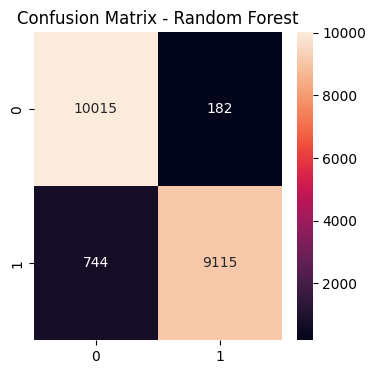

In [768]:
cm_rf = confusion_matrix(y_test, y_pred_rf1)
plt.figure(figsize=(4,4))
sns.heatmap(cm_rf, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()

#### 7.ADABOOST

In [760]:
ada=AdaBoostClassifier()
ada.fit(x_train, y_train)
y_pred_ada = ada.predict(x_test)
print(y_pred_ada)

print("ADA BOOST Accuracy:", accuracy_score(y_test, y_pred_ada))

[1 1 1 ... 0 1 0]
ADA BOOST Accuracy: 0.8621858795372955


#### After Hyperparameter tuning

In [761]:
ada_param = {
    'n_estimators': [50, 100],
    'learning_rate': [0.5, 1.0]
}
ada_grid=GridSearchCV(ada, param_grid=ada_param, cv=3, scoring='accuracy')
ada_grid.fit(x_train, y_train)
print("Best parameters:", ada_grid.best_params_)

Best parameters: {'learning_rate': 1.0, 'n_estimators': 100}


In [762]:
ada1=AdaBoostClassifier(n_estimators=100, learning_rate=1.0)
ada1.fit(x_train, y_train)

y_pred_ada1 = ada1.predict(x_test)
print(y_pred_ada1)

print("ADA BOOST\n_______________________________________\n")
print(" After Hyperparameter Tuning - ADA BOOST Accuracy:", accuracy_score(y_test, y_pred_ada1))

print("\nTest Score  : ",ada1.score(x_test,y_test))
print("Train Score : ",ada1.score(x_train,y_train))

print("\nClassification report:\n", classification_report(y_test, y_pred_ada1))

[1 1 0 ... 0 1 0]
ADA BOOST
_______________________________________

 After Hyperparameter Tuning - ADA BOOST Accuracy: 0.8909553250897487

Test Score  :  0.8909553250897487
Train Score :  0.8904068607897886

Classification report:
               precision    recall  f1-score   support

           0       0.87      0.92      0.90     10197
           1       0.91      0.86      0.89      9859

    accuracy                           0.89     20056
   macro avg       0.89      0.89      0.89     20056
weighted avg       0.89      0.89      0.89     20056



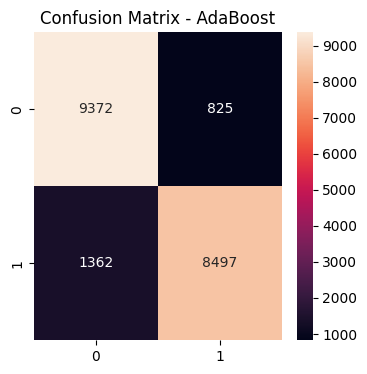

In [771]:
cm_ada = confusion_matrix(y_test, y_pred_ada1)
plt.figure(figsize=(4,4))
sns.heatmap(cm_ada, annot=True, fmt='d')
plt.title("Confusion Matrix - AdaBoost")
plt.show()

### 8.GRADIENTBOOST

In [767]:
gb=GradientBoostingClassifier()
gb.fit(x_train, y_train)
y_pred_gb = gb.predict(x_test)
print(y_pred_gb)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))

[1 1 0 ... 0 1 0]
Gradient Boosting Accuracy: 0.9268049461507778


#### After Hyperparameter Tuning

In [772]:
gb_param = {
    'n_estimators': [50, 100],
    'learning_rate': [0.5, 1.0],
    'max_depth': [3, 5]
}
gb_grid=GridSearchCV(gb, param_grid=gb_param, cv=3, scoring='accuracy')
gb_grid.fit(x_train, y_train)
print("Best parameters:", gb_grid.best_params_)

Best parameters: {'learning_rate': 0.5, 'max_depth': 5, 'n_estimators': 100}


In [774]:
gb1=GradientBoostingClassifier(n_estimators=100, learning_rate=0.5,max_depth=5)
gb1.fit(x_train, y_train)

y_pred_gb1 = gb1.predict(x_test)
print(y_pred_gb1)

print("ADA BOOST\n_______________________________________\n")
print(" After Hyperparameter Tuning - ADA BOOST Accuracy:", accuracy_score(y_test, y_pred_gb1))

print("\nTest Score  : ",gb1.score(x_test,y_test))
print("Train Score : ",gb1.score(x_train,y_train))

print("\nClassification report:\n", classification_report(y_test, y_pred_gb1))

[1 1 0 ... 0 1 0]
ADA BOOST
_______________________________________

 After Hyperparameter Tuning - ADA BOOST Accuracy: 0.9492421220582369

Test Score  :  0.9492421220582369
Train Score :  0.9603235939369764

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.98      0.95     10197
           1       0.98      0.92      0.95      9859

    accuracy                           0.95     20056
   macro avg       0.95      0.95      0.95     20056
weighted avg       0.95      0.95      0.95     20056



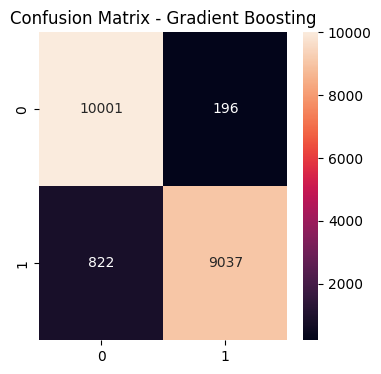

In [775]:
cm_gb = confusion_matrix(y_test, y_pred_gb1)
plt.figure(figsize=(4,4))
sns.heatmap(cm_gb, annot=True, fmt='d')
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()

### 9.XGBOOST

In [817]:
xgb = XGBClassifier()
xgb.fit(x_train, y_train)
y_pred_xgb = xgb.predict(x_test)
print(y_pred_xgb)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))

[1 1 0 ... 0 1 0]
Gradient Boosting Accuracy: 0.9268049461507778


#### After Hyperparameter Tuning

In [788]:
xgb_param = {
    'n_estimators': [100,200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}
xgb_grid=GridSearchCV(xgb,param_grid=xgb_param,
    cv=3,
    scoring='accuracy')
xgb_grid.fit(x_train, y_train)
print("Best parameters:", xgb_grid.best_params_)

Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


In [789]:
xgb1=XGBClassifier(n_estimators=200, learning_rate=0.1,max_depth=5)
xgb1.fit(x_train, y_train)

y_pred_xgb1 = xgb1.predict(x_test)
print(y_pred_xgb1)

print("XG BOOST\n_______________________________________\n")
print("\n After Hyperparameter Tuning - XG BOOST Accuracy:", accuracy_score(y_test, y_pred_xgb1))

print("\nTest Score  : ",xgb1.score(x_test,y_test))
print("Train Score : ",xgb1.score(x_train,y_train))

print("\nClassification report:\n", classification_report(y_test, y_pred_xgb1))

[1 1 0 ... 0 1 0]
XG BOOST
_______________________________________


 After Hyperparameter Tuning - XG BOOST Accuracy: 0.9465496609493419

Test Score  :  0.9465496609493419
Train Score :  0.9465995213402473

Classification report:
               precision    recall  f1-score   support

           0       0.91      0.99      0.95     10197
           1       0.99      0.90      0.94      9859

    accuracy                           0.95     20056
   macro avg       0.95      0.95      0.95     20056
weighted avg       0.95      0.95      0.95     20056



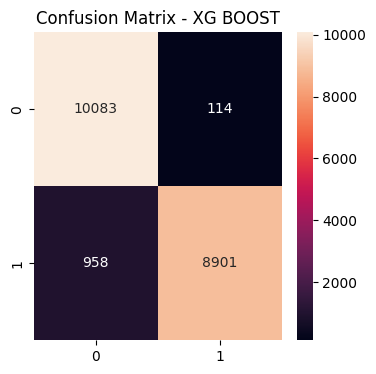

In [795]:
cm_xg = confusion_matrix(y_test, y_pred_xgb1)
plt.figure(figsize=(4,4))
sns.heatmap(cm_xg, annot=True, fmt='d')
plt.title("Confusion Matrix - XG BOOST")
plt.show()

In [797]:
# Logistic
lgtt = accuracy_score(y_test,y_pred_l1)
lgtrt = logistic1.score(x_train, y_train)

# KNN
knntt = accuracy_score(y_test, y_pred_knn1)
knnrt = knn1.score(x_train, y_train)

# SVM
svmtt = accuracy_score(y_test, y_pred_svm1)
svmrt = svm1.score(x_train, y_train)

# Naive Bayes
nbtt = accuracy_score(y_test, y_pred_nb1)
nbtrt = nb1.score(x_train, y_train)

# Decision Tree
dttt = accuracy_score(y_test, y_pred_dt1)
dttrt = dt1.score(x_train, y_train)

# Random Forest
rftt = accuracy_score(y_test, y_pred_rf1)
rfrt = rf1.score(x_train, y_train)

# AdaBoost
adbtt = accuracy_score(y_test, y_pred_ada1)
adbrt = ada1.score(x_train, y_train)

# Gradient Boost
gbtt = accuracy_score(y_test, y_pred_gb1)
gbrt = gb1.score(x_train, y_train)

# XGBoost
xgbtt = accuracy_score(y_test, y_pred_xgb1)
xgbrt = xgb1.score(x_train, y_train)

In [798]:
tb1=pd.DataFrame()
tb1['Model']=pd.Series(['Logistic Regression','K-Nearest Neighbors','Support Vector Machine','Naive Bayes','Decision Tree','Random Forest','AdaBoost','Gradient Boosting','XG BOOST'])
tb1['Test Accuracy']=pd.Series([lgtt,knntt,svmtt,nbtt,dttt,rftt,adbtt,gbtt,xgbtt])
tb1['Train Accuracy']=pd.Series([lgtrt,knnrt,svmrt,nbtrt,dttrt,rfrt,adbrt,gbrt,xgbrt])
tb1

,Model,Test Accuracy,Train Accuracy
0,Logistic Regression,0.702682,0.707569
1,K-Nearest Neighbors,0.906362,1.000000
2,Support Vector Machine,0.850469,0.871722
3,Naive Bayes,0.713702,0.720533
4,Decision Tree,0.909204,0.908581
5,Random Forest,0.953829,1.000000
6,AdaBoost,0.890955,0.890407
7,Gradient Boosting,0.949242,0.960324
8,XG BOOST,0.946550,0.946600


In [800]:
model=xgb1
model


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [813]:
import joblib
joblib.dump(model,'./employee_model.pkl')

['C:/Users/Lenovo/Project/employee_model.pkl']

In [814]:
joblib.dump(l1,'./l1.pkl')
joblib.dump(l2,'./l2.pkl')
joblib.dump(l3,'./l3.pkl')
joblib.dump(l4,'./l4.pkl') 
joblib.dump(scaler,'./scaler.pkl')

['C:/Users/Lenovo/Project/scaler.pkl']

In [815]:
joblib.dump(oe,'./oe.pkl')

['C:/Users/Lenovo/Project/oe.pkl']